# Gene Clustering: Building Phylogenetic Trees

*Authors: Naroa Iparraguirre and Urtats Berrocal*

In this exercise, we will compare a specific gene shared across different organisms and draw a phylogenetic tree (a "family tree" of DNA) based on how similar those genes are. 

By measuring the genetic distance between species, we can infer evolutionary relationships. To accomplish this, we will use three main computational steps:
1. **Sequence Alignment:** Using Biopython to calculate how closely the sequences match.
2. **Hierarchical Clustering:** Using SciPy to group the sequences based on their alignment scores.
3. **Visualization:** Using Matplotlib to draw dendrograms so we can visually compare different clustering algorithms.

## 1. Environment Setup & Libraries

First, we need to install and import the external tools (libraries) required for our analysis. 

* `Biopython`: Essential for reading biological sequence files (`.fasta`) and performing the complex sequence alignments.
* `NumPy`: To handle our mathematical distance matrix efficiently.
* `SciPy`: Contains the math to compact our matrix and calculate the hierarchical clusters.
* `Matplotlib & Pylab`: To draw the actual graphs and tree structures.

In [1]:
# Install required packages (uncomment if running for the first time)
# %pip install biopython scipy matplotlib numpy

from Bio import SeqIO
from Bio import Align
import numpy as np
import os
import matplotlib.pyplot as plt
import scipy.spatial.distance as distance
from scipy.cluster.hierarchy import linkage, dendrogram

PATH = 'data/'
FILENAME1 = PATH + 'opuntia.fasta'
FILENAME2 = PATH + 'ls_orchid.fasta'

# 2. Helper Functions

## 2.1. Defining Data Parsers

We are writing a custom function called `read_seqs()` to load our `.fasta` files into Python.

While Biopython has built-in parsers, wrapping it in our own function allows us to add "error handling". If a file is missing or empty, our code will print a warning instead of crashing the whole notebook.

In [2]:
def read_seqs(filename, format='fasta'):
    """
    Read sequences from a file and return a list of SeqRecord objects.
    Includes error handling for missing or empty files.
    """
    if not os.path.exists(filename):
        print(f"Error: The file '{filename}' does not exist.")
        return []

    try:
        # Using list() on the generator to load records into memory
        seq_records = list(SeqIO.parse(filename, format))
        
        if seq_records:
            print(f"{len(seq_records)} records found in '{filename}' ({format}).")
        else:
            print(f"Warning: No records found in '{filename}'. Check the file format.")
            
        return seq_records

    except Exception as e:
        print(f"An error occurred while parsing {filename}: {e}")
        return []

## 2.2. Calculating the Distance Matrix

We are building a function to calculate a 2D matrix that represents the evolutionary distance between every possible pair of sequences. 

Computers need numbers, not letters, to cluster data. We use a `blastn` scoring scheme to reward similarities and penalize differences:
* **Match (+2):** Nucleotides are identical.
* **Mismatch (-3):** Nucleotides differ (mutation).
* **Gap Open (-7):** Heavy penalty for an insertion/deletion.
* **Gap Extend (-2):** Lighter penalty for continuing a gap.

Because longer sequences naturally get higher scores, we must **normalize** the score by dividing it by the maximum possible score ($2 \times \text{mean length}$). Finally, we convert this similarity score ($s$) into a distance ($d$) using the formula: $d = 1 - s$.

In [3]:
def distance_matrix(aligner, seq_records):
    """
    Computes a symmetric distance matrix for a list of sequences.
    Dynamically adjusts normalization based on the aligner's match score.
    """
    num_seqs = len(seq_records)
    dm = np.zeros((num_seqs, num_seqs))
    
    # If aligner.match_score is None (e.g., standard 'blastn'), default to 2.0.
    # Otherwise, use the custom match score provided.
    match_reward = aligner.match_score if aligner.match_score is not None else 2.0

    for i in range(num_seqs):
        seq_i = seq_records[i].seq
        
        for j in range(i, num_seqs):
            seq_j = seq_records[j].seq

            if i == j: 
                dist = 0.0
            else:
                raw_score = aligner.score(seq_i, seq_j)
                len_mean = (len(seq_i) + len(seq_j)) / 2
                
                # Normalize using our safe match_reward
                max_possible_score = match_reward * len_mean
                similarity = raw_score / max_possible_score if max_possible_score > 0 else 0
                
                dist = 1 - similarity

            dm[i][j] = dist
            dm[j][i] = dist
            
    return dm

## 2.3. Hierarchical Clustering Visualization

We are converting our 2D matrix into a compacted 1D array (`squareform`), calculating the hierarchical clusters (`linkage`), and plotting them as dendrograms. 

Different algorithms define the "distance between clusters" differently. 
* **Single:** Connects based on the closest neighbors.
* **Complete:** Connects based on the furthest neighbors.
* **Average (UPGMA):** Connects based on the average distance (standard in biology).
* **Ward:** Minimizes the variance within clusters.

We are going to plot them side-by-side with synchronized X-axes to clearly see how the algorithm choice affects the shape of our phylogenetic tree.

In [4]:
def plot_dendograms(cdm, methods, names, title="", figsize=(15, 30)):
    """
    Plots a 2x2 grid of dendrograms.
    """
    hierarchies = {m: linkage(cdm, method=m) for m in methods}
    max_dist = max([h[:, 2].max() for h in hierarchies.values()])

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    if title:
        fig.suptitle(title, fontsize=20, fontweight='bold')
        
    axes = axes.flatten()

    for i, method in enumerate(methods):
        dendrogram(
            hierarchies[method], 
            labels=names, 
            orientation='right', 
            ax=axes[i], 
            leaf_font_size=8 
        )
        
        axes[i].set_xlim(0, max_dist * 1.05)
        axes[i].set_title(f"Linkage Method: {method.capitalize()}", fontsize=14, fontweight='bold')
        axes[i].set_xlabel("Evolutionary Distance")

    # Adjusted the rect slightly so the title fits on a much taller image
    plt.tight_layout(rect=[0, 0, 1, 0.98]) 
    plt.show()

# 3. Analyzing Opuntia.fasta

In this section, we will analyze the `opuntia.fasta` dataset. However, we are going to add a layer of complexity: we will compare how the **scoring scheme** of our sequence aligner affects the final phylogenetic tree. 

The aligner acts as a referee, giving points for matches and subtracting points for mutations (mismatches and gaps). If we change the rules of the game (the scoring scheme), the aligner will interpret the sequence similarities differently. We will compare a standard `blastn` scheme against a custom "Extreme Mismatch-Averse" scheme to see if the evolutionary tree changes shape.

## Step 1: Load Data and Extract Names
First, we need to load our `.fasta` file using the `read_seqs()` function we built earlier. Then, we will extract a clean species name from the Biopython sequence header to use as labels for our dendrograms.

In [5]:
# Read the sequences from the file
seq_records = read_seqs(FILENAME1)

# Extract clean names by splitting the FASTA header string
names = [seq_req.name.split('|')[3] for seq_req in seq_records]

7 records found in 'data/opuntia.fasta' (fasta).


## Step 2: Calculate Baseline Distance Matrix (BLASTN)
We will generate our first distance matrix using the standard `blastn` rules. This will act as our "control" matrix so we have a baseline to compare against.

In [6]:
# Create the standard aligner and compute the baseline distance matrix
aligner_blastn = Align.PairwiseAligner(scoring='blastn')
dm_blastn = distance_matrix(aligner_blastn, seq_records)

## Step 3: Calculate Custom Distance Matrix
Now, we will define a custom scoring scheme. Notice the specific values we are setting:
* **Match (+5):** Huge reward for identical bases.
* **Mismatch (-20):** A catastrophic penalty for aligning different bases.
* **Gap Open (-1):** Almost no penalty for starting a gap.
* **Gap Extend (-0.1):** It costs basically nothing to make the gap massive.

Instead of forcing two slightly different sequences to align, this aligner will brutally slice the sequences apart, inserting massive gaps everywhere just to guarantee that the only bases lining up are perfect matches.

In [7]:
# Create a blank aligner and apply custom rules
aligner_custom = Align.PairwiseAligner()

aligner_custom.match_score = 5
aligner_custom.mismatch_score = -20
aligner_custom.open_gap_score = -1
aligner_custom.extend_gap_score = -0.1

# Compute the custom distance matrix
dm_custom = distance_matrix(aligner_custom, seq_records)

## Step 4: Compact Matrices and Plot
Finally, SciPy requires our 2D distance matrices to be flattened into a 1D condensed array before it can calculate the clusters. We will compact both matrices and pass them into our plotting function. 

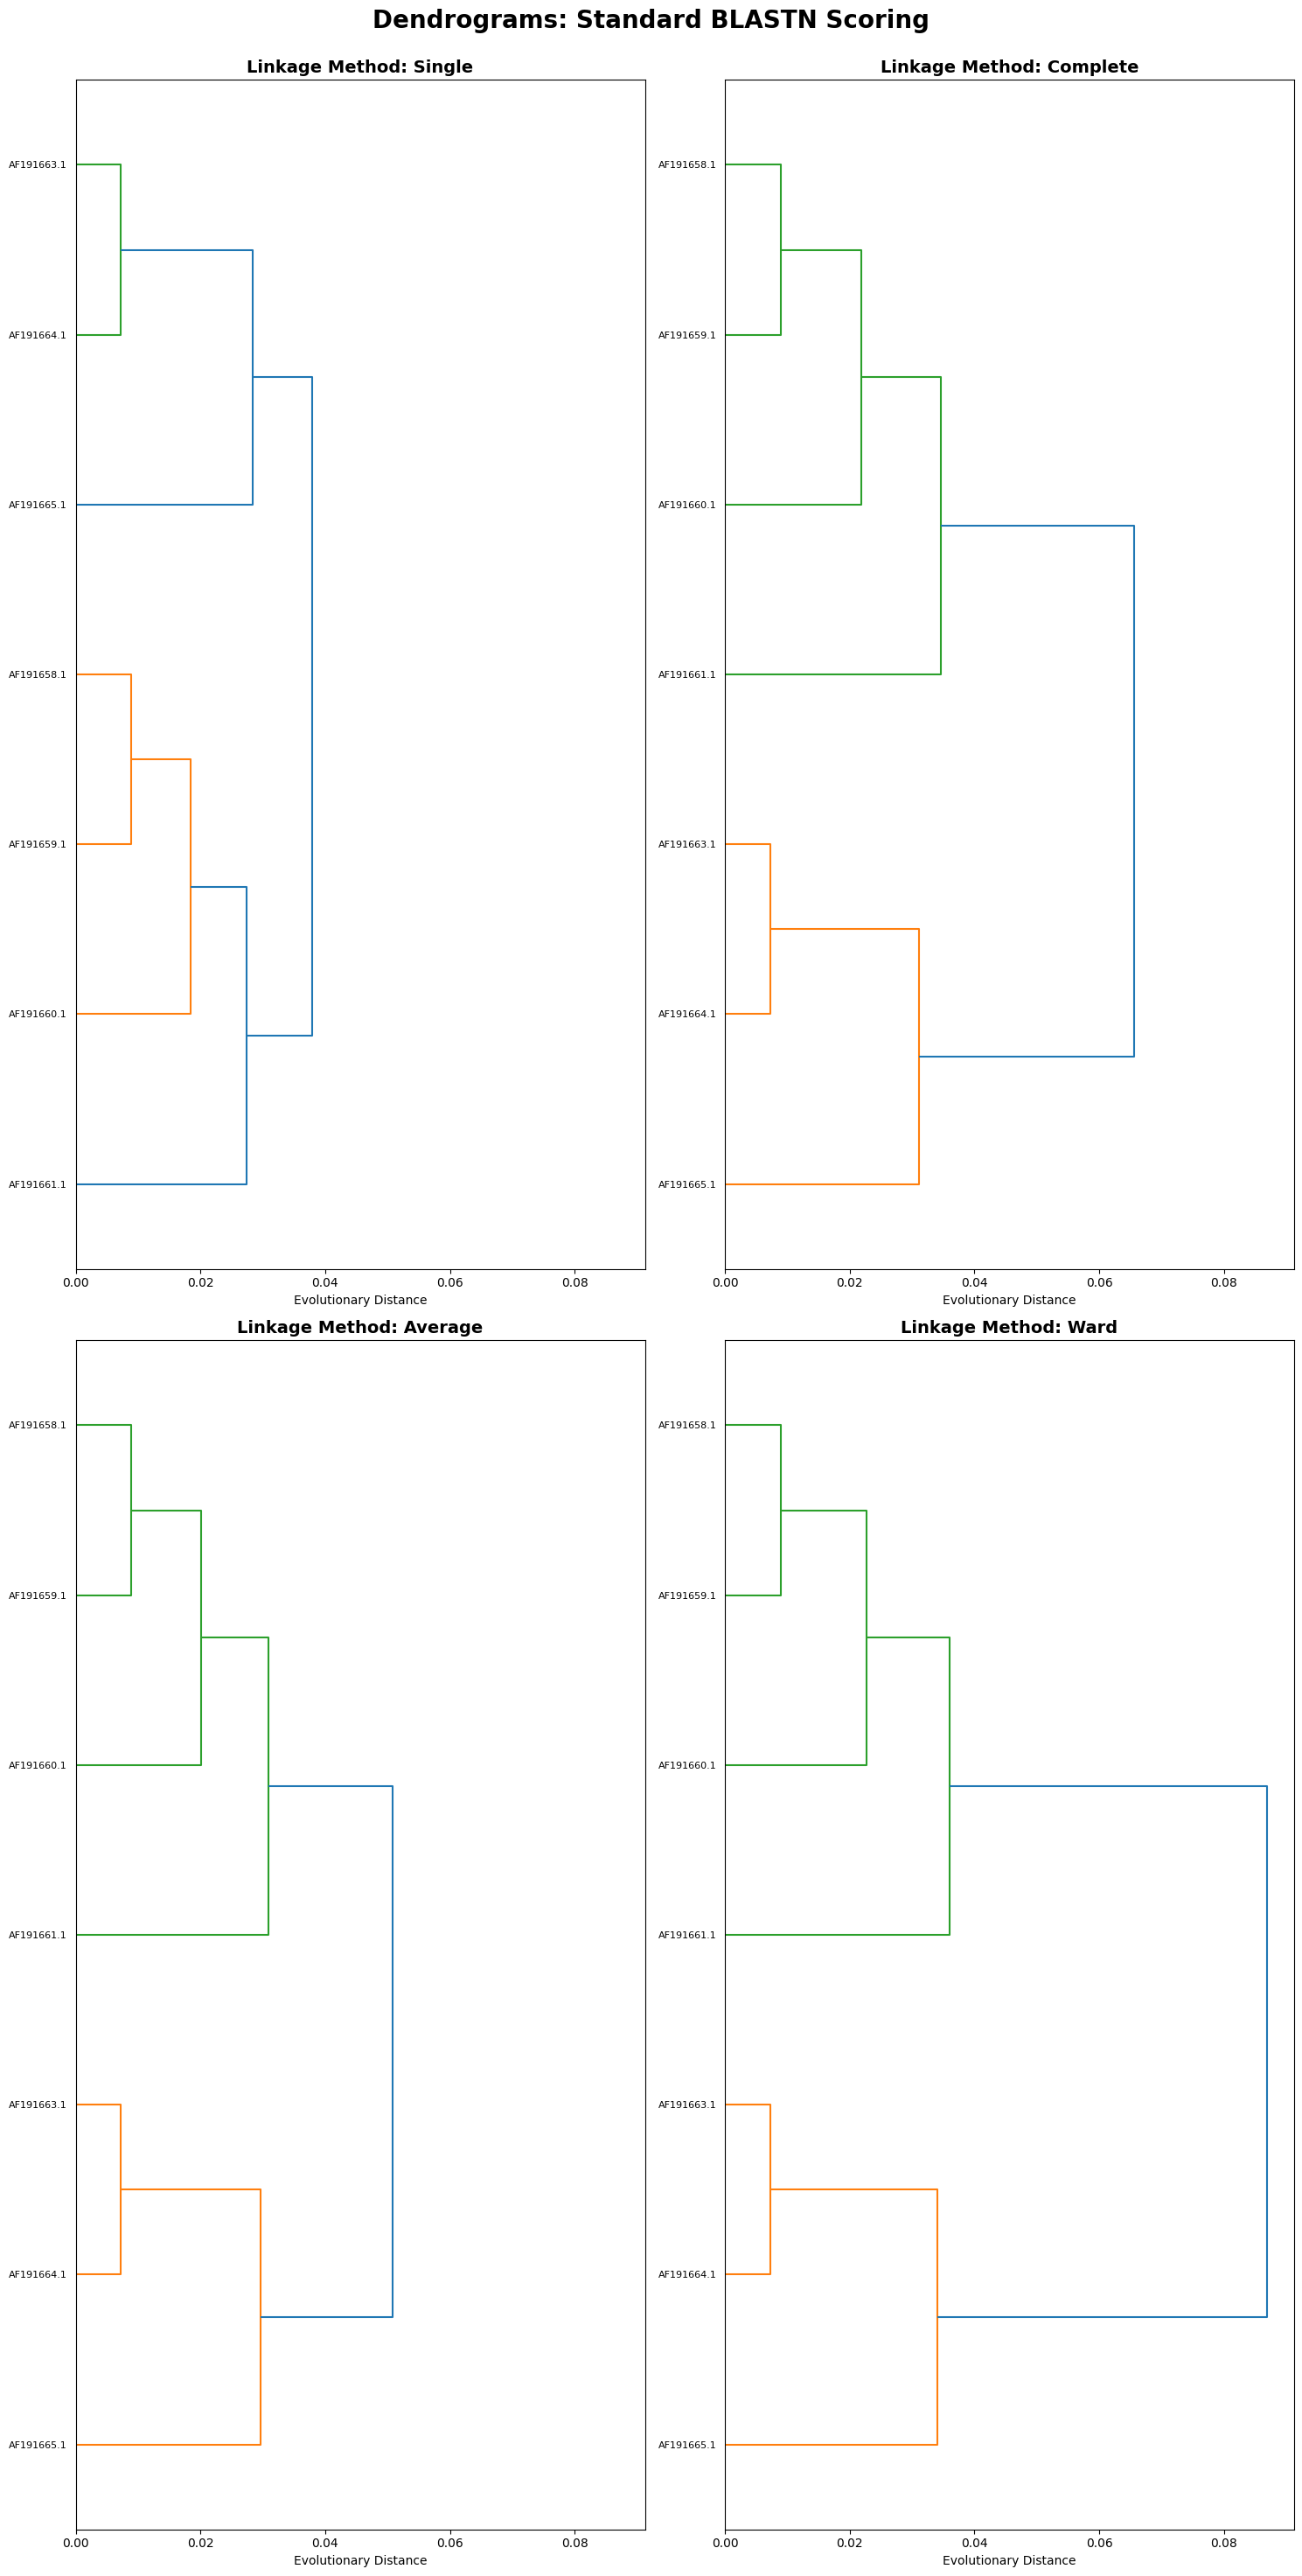

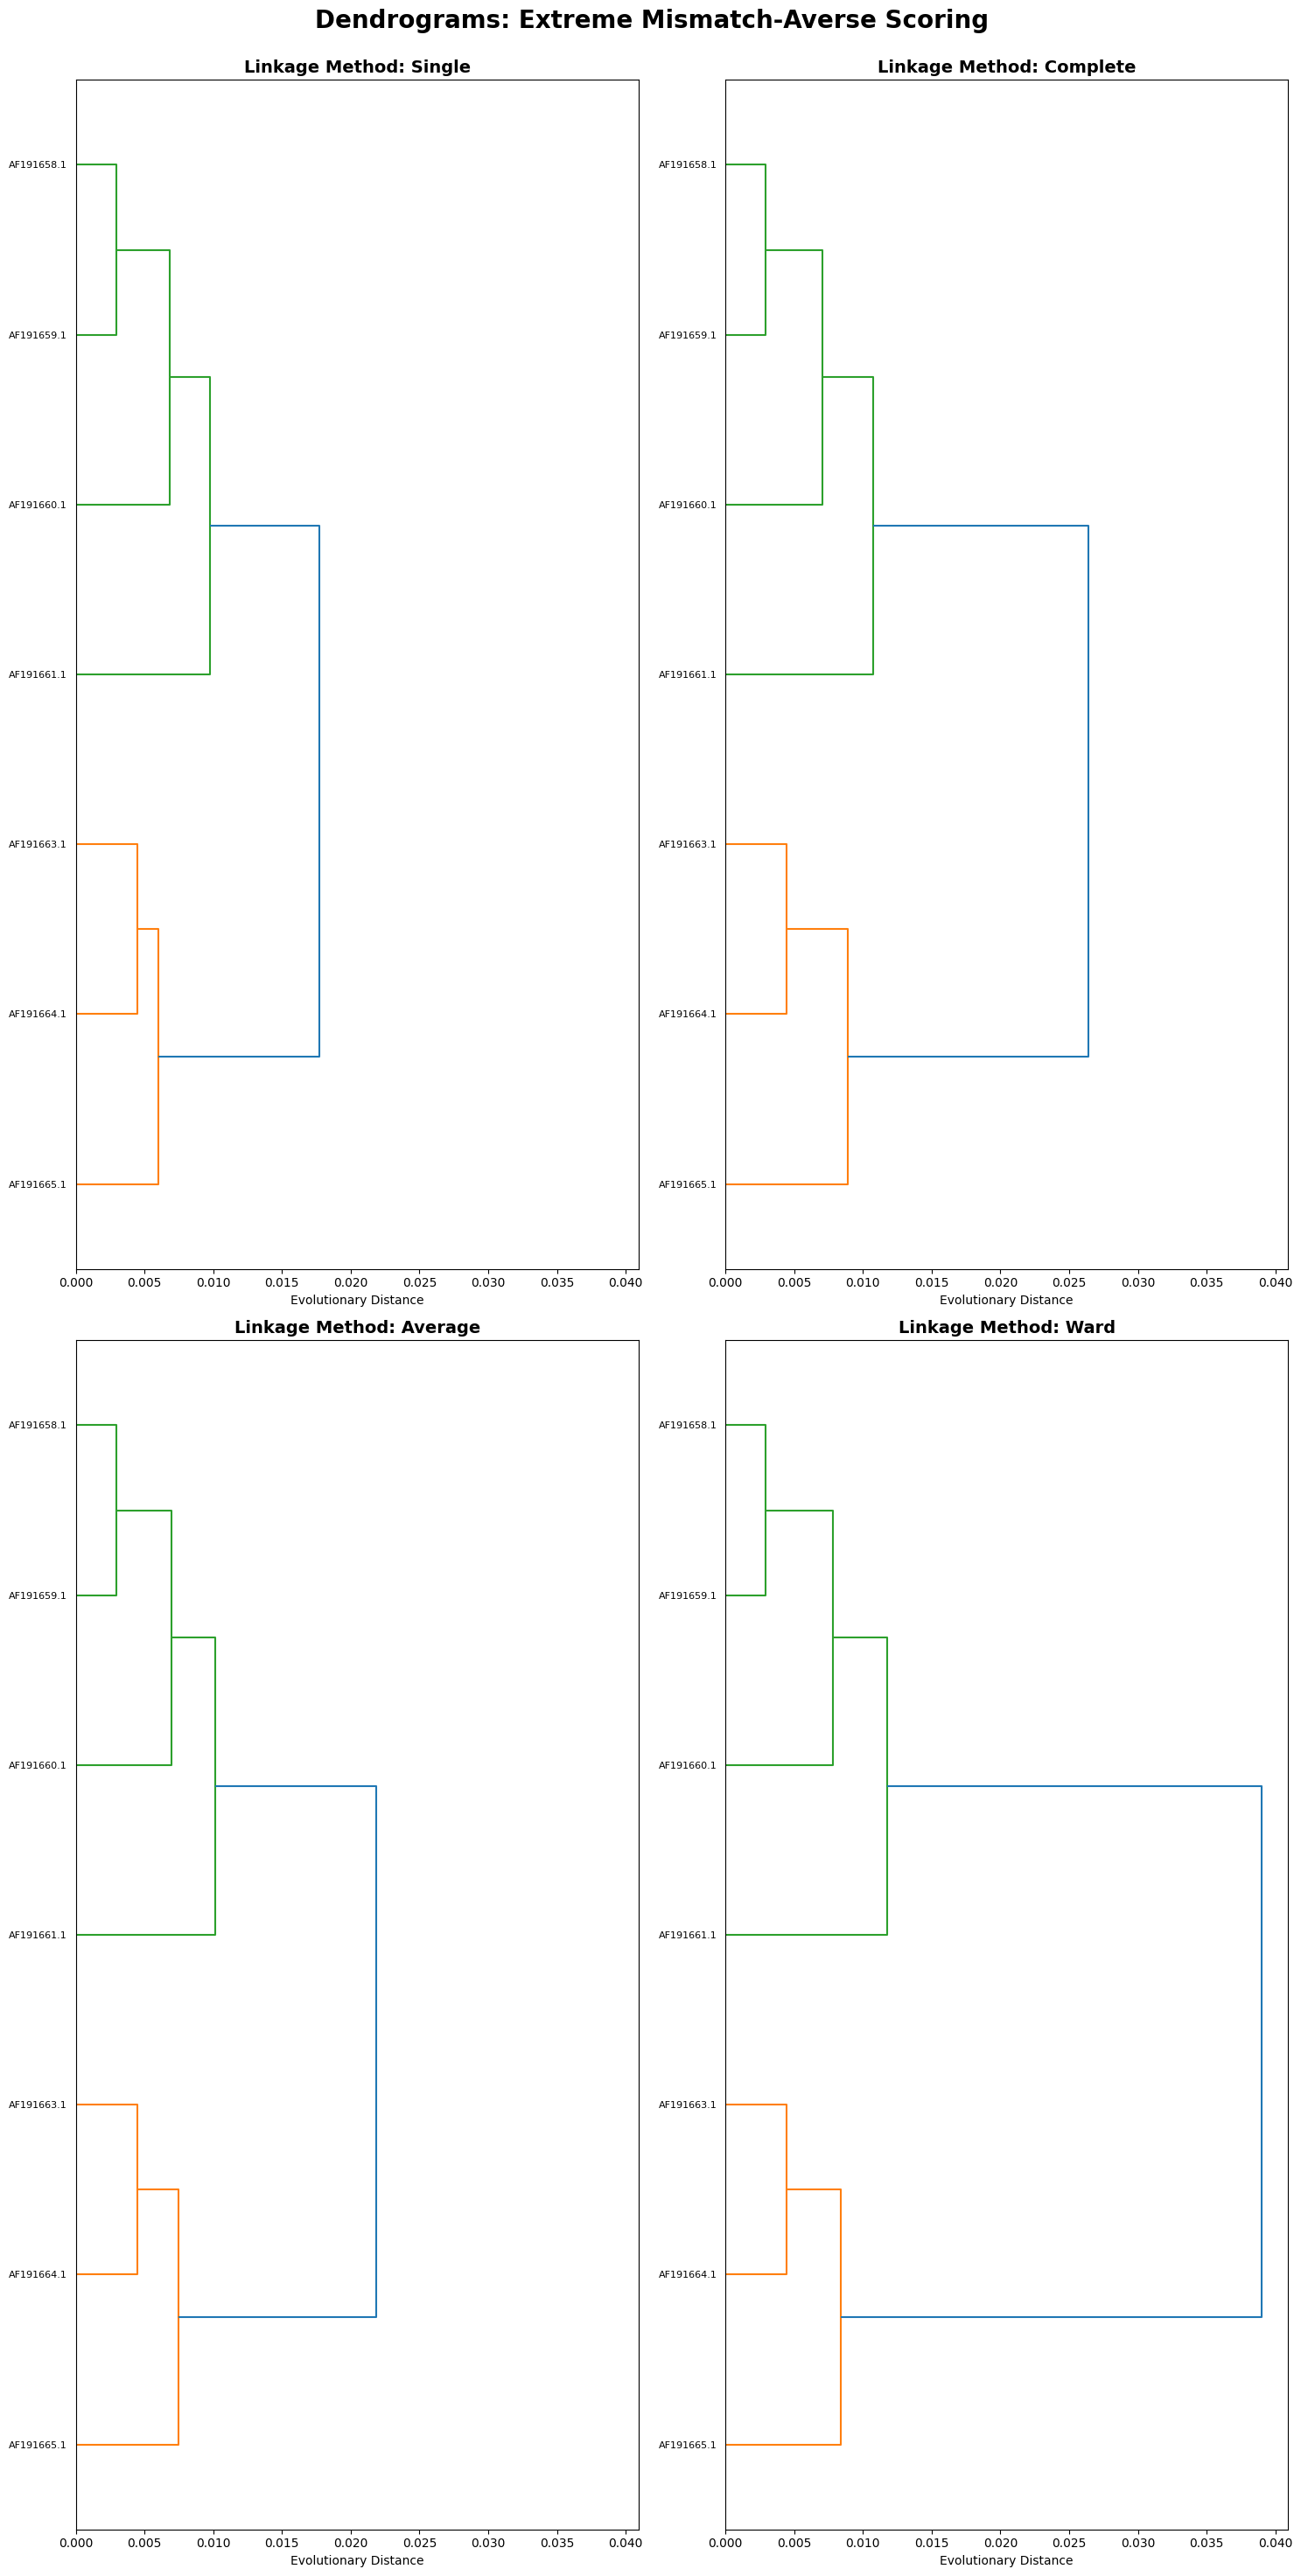

In [8]:
# Compact both matrices for SciPy's linkage function
cdm_blastn = distance.squareform(dm_blastn)
cdm_custom = distance.squareform(dm_custom)

# Define the linkage methods to evaluate
methods = ['single', 'complete', 'average', 'ward']

# Plot the baseline (BLASTN) dendrograms
plot_dendograms(
    cdm_blastn, 
    methods, 
    names, 
    title="Dendrograms: Standard BLASTN Scoring"
)

# Plot the custom scoring dendrograms
plot_dendograms(
    cdm_custom, 
    methods, 
    names, 
    title="Dendrograms: Extreme Mismatch-Averse Scoring"
)

In this experiment, we compared the standard `BLASTN` scoring scheme against an **"Extreme Mismatch-Averse"** custom scheme (Match: +5, Mismatch: -20, Gap Open: -1, Gap Extend: -0.1). By comparing the resulting dendrograms side-by-side, we observed how the mathematical rules of sequence alignment dictate the shape and scale of our evolutionary trees.

* **1. Topological Robustness (The Branches Stayed Similar):**

    Despite drastically changing the rules, the overarching structure of the tree remained largely intact. Across both schemes, the *Opuntia* sequences cleanly divide into two main clades (families): 
    * **Group 1:** AF191658.1, AF191659.1, AF191660.1, and AF191661.1
    * **Group 2:** AF191663.1, AF191664.1, and AF191665.1
    * *Conclusion:* This suggests that the evolutionary divergence between these two groups is biologically very strong. It takes more than just tweaking the aligner's penalties to break this primary relationship.

* **2. A Drastic Shift in the Distance Scale (Look at the X-Axis):**

    The most striking difference is the massive compression of the evolutionary distances. 
    * In the **BLASTN** model, the maximum distance (using Ward's linkage) is roughly **0.08**.
    * In the **Extreme** model, the maximum distance plummets to roughly **0.008**—a tenfold decrease.

* **3. The Mechanics of the Extreme Aligner:**

    Why did the distances shrink to near zero? Because we made gaps practically "free" (-1 open / -0.1 extend) and mismatches catastrophic (-20), the aligner refused to align different bases. Instead, it tore the sequences apart, inserting massive gaps just to ensure that the only bases aligning were perfect matches. 
    * Because our formula calculates distance based on the normalized match score, an alignment made almost entirely of perfect matches (padded by cheap gaps) results in a similarity score approaching `1.0`. 
    * Since $d = 1 - s$, a near-perfect similarity yields an artificially tiny distance.

While extreme scoring schemes are excellent for stress-testing how robust your clades are, standard schemes like BLASTN are the gold standard for a reason. They represent a biologically realistic balance—acknowledging that point mutations (mismatches) are often more evolutionarily common than massive insertions or deletions (gaps).

# 4. Analyzing is_orchid.fasta

We are now scaling up our analysis to a much larger dataset: `ls_orchid.fasta`, which contains nearly 100 orchid sequences. We will use this complex dataset to test our standard `BLASTN` aligner against an "Extreme Mismatch-Averse" custom aligner. 

Larger datasets are much more difficult to cluster cleanly. By applying an extreme scoring scheme (where mismatches are heavily penalized but gaps are virtually free), we can stress-test the clustering algorithms to see if the biological "families" hold together or completely collapse under bizarre mathematical rules.

## Step 1: Load Data and Extract Names
Just like before, we start by loading our `.fasta` file. Because this file has roughly 100 sequences, extracting clean, short names from the Biopython header is absolutely critical so our final dendrogram doesn't become an unreadable wall of text.

In [9]:
# Read the sequences from the file
seq_records = read_seqs(FILENAME2)

# Extract clean names by splitting the FASTA header string
names = [seq_req.name.split('|')[3] for seq_req in seq_records]

94 records found in 'data/ls_orchid.fasta' (fasta).


## Step 2: Calculate Baseline Distance Matrix (BLASTN)
We need a reliable baseline to compare against. We will use the standard `blastn` scoring scheme to generate a biologically realistic distance matrix. This acts as our "control" group.

In [10]:
# Create the standard aligner and compute the baseline distance matrix
aligner_blastn = Align.PairwiseAligner(scoring='blastn')
dm_blastn = distance_matrix(aligner_blastn, seq_records)

## Step 3: Calculate Custom Distance Matrix (Extreme Mismatch-Averse)
Here, we define our extreme rules. We are telling the aligner:
* **Match (+5):** Reward matches heavily.
* **Mismatch (-20):** Punish point mutations catastrophically.
* **Gaps (-1 open / -0.1 extend):** Make insertions and deletions incredibly cheap.

This will force the aligner to shred the sequences with gaps just to line up perfect matches, drastically compressing our evolutionary distances.

In [11]:
# Create a blank aligner and apply custom rules
aligner_custom = Align.PairwiseAligner()

aligner_custom.match_score = 5
aligner_custom.mismatch_score = -20
aligner_custom.open_gap_score = -1
aligner_custom.extend_gap_score = -0.1

# Compute the custom distance matrix
dm_custom = distance_matrix(aligner_custom, seq_records)

## Step 4: Compact Matrices and Plot
Finally, we compress our 2D matrices into 1D arrays using SciPy's `squareform` and plot them side-by-side. Thanks to the dynamic figure sizing we built into our `plot_dendograms` function earlier, it will automatically stretch the canvas vertically to fit all 100 orchid names without overlapping.

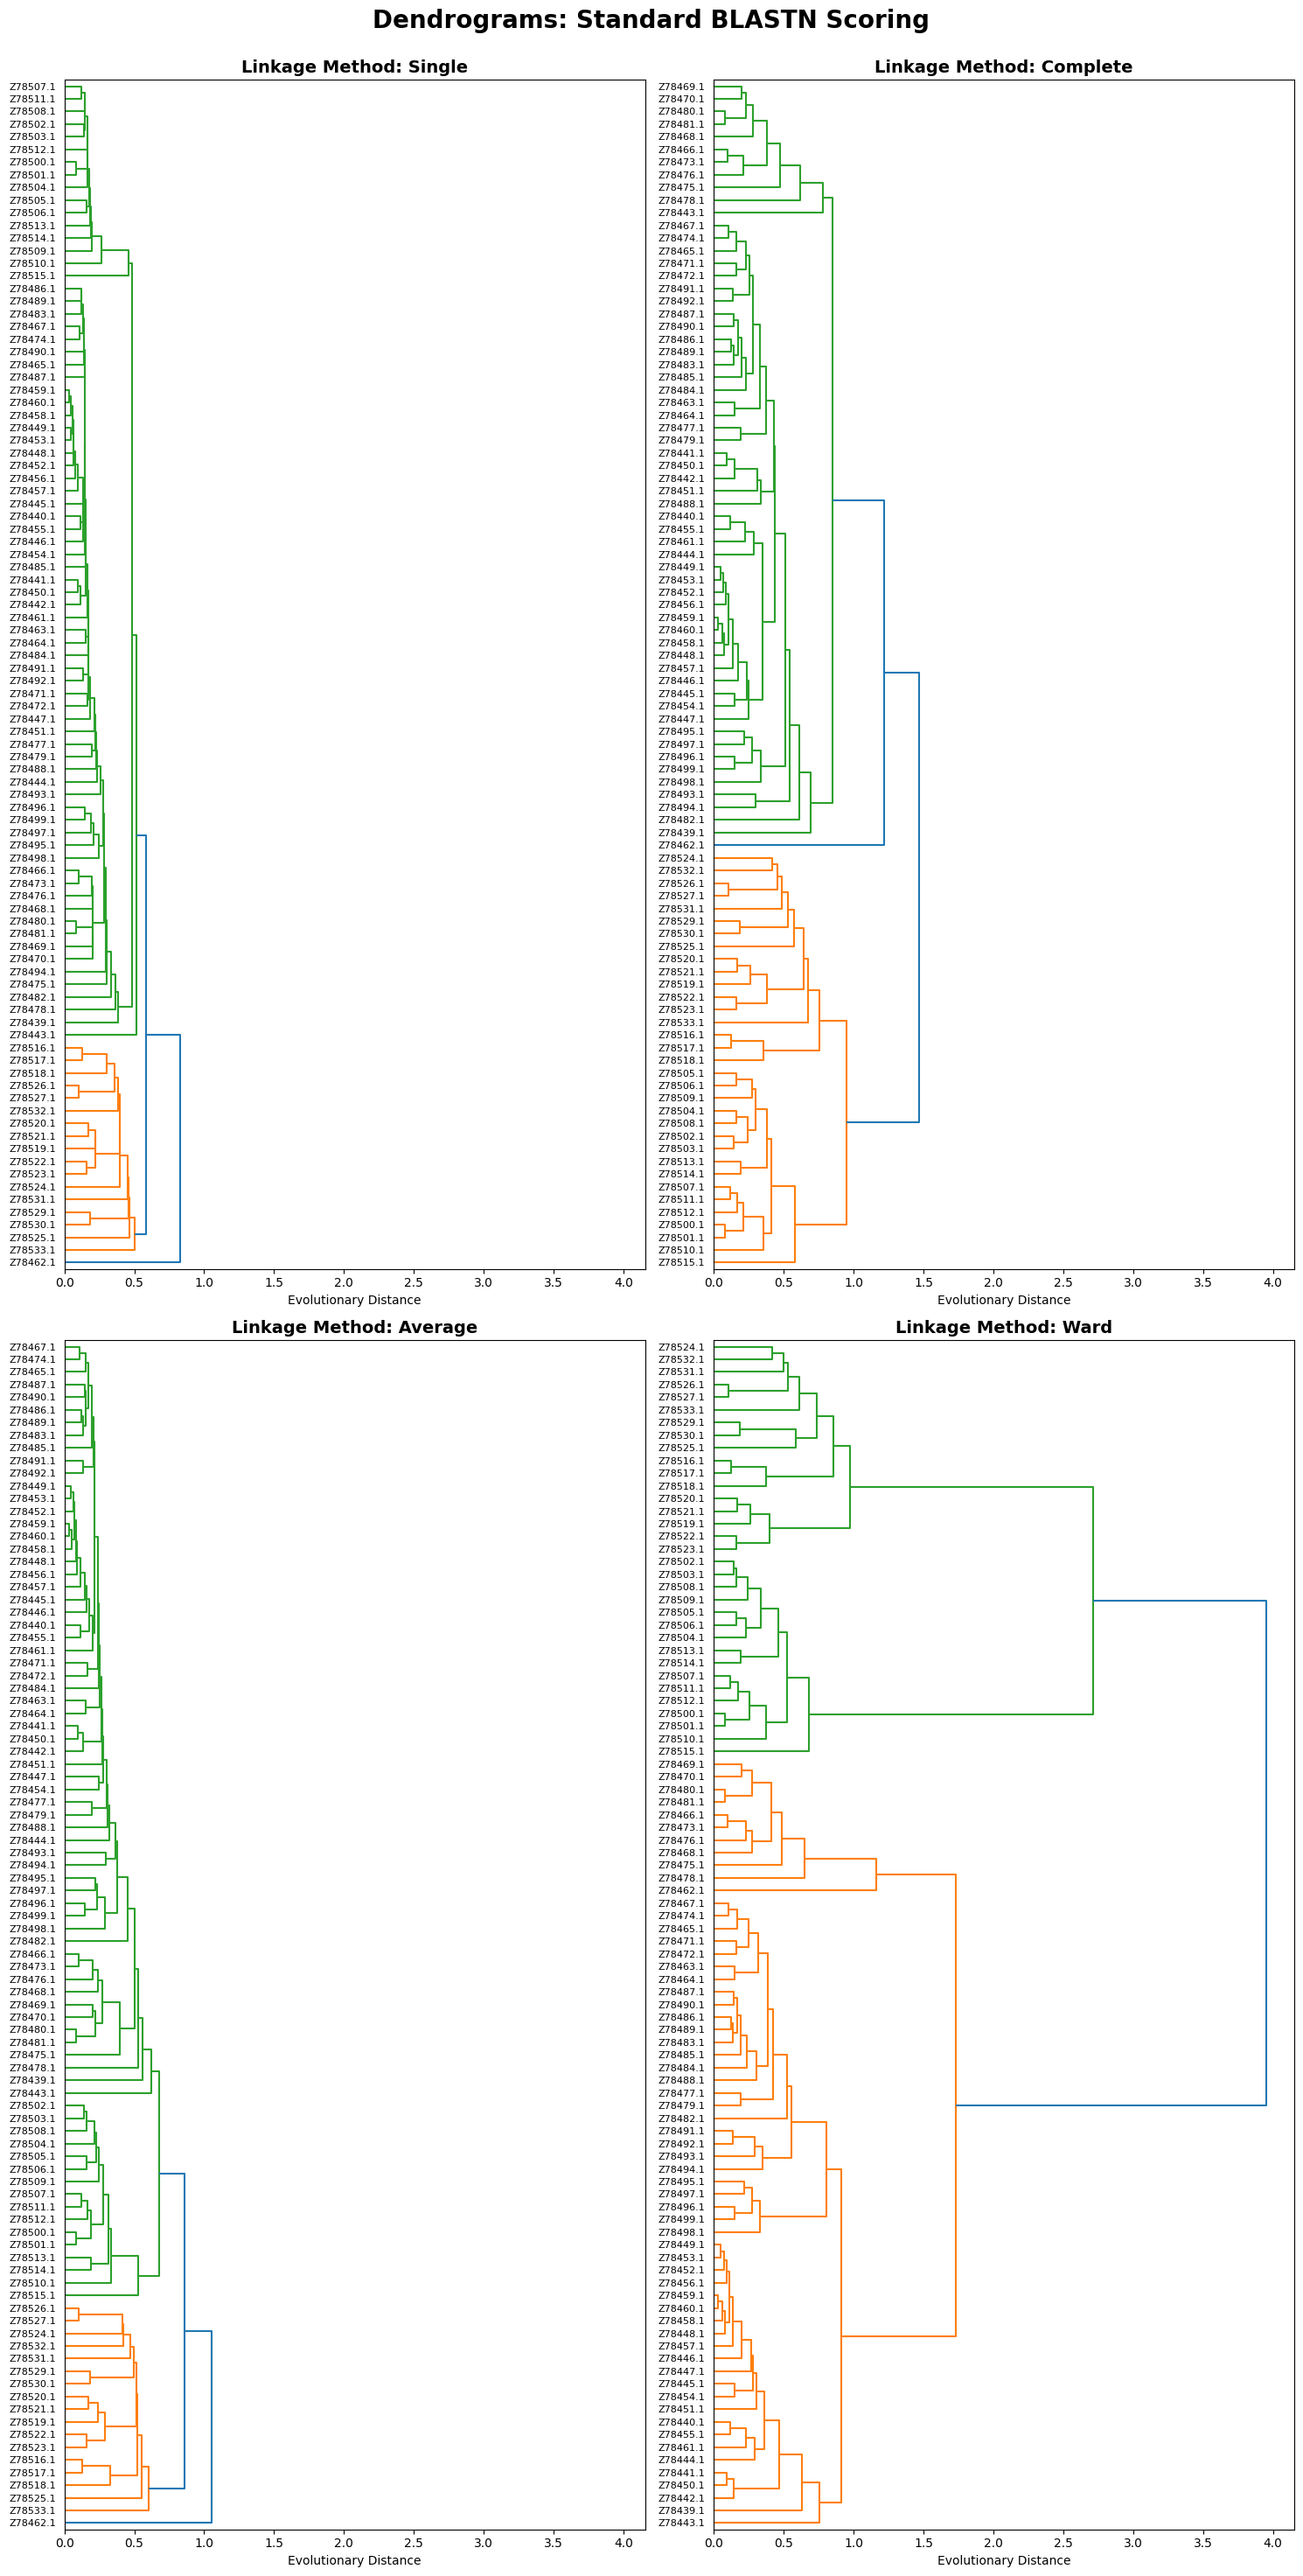

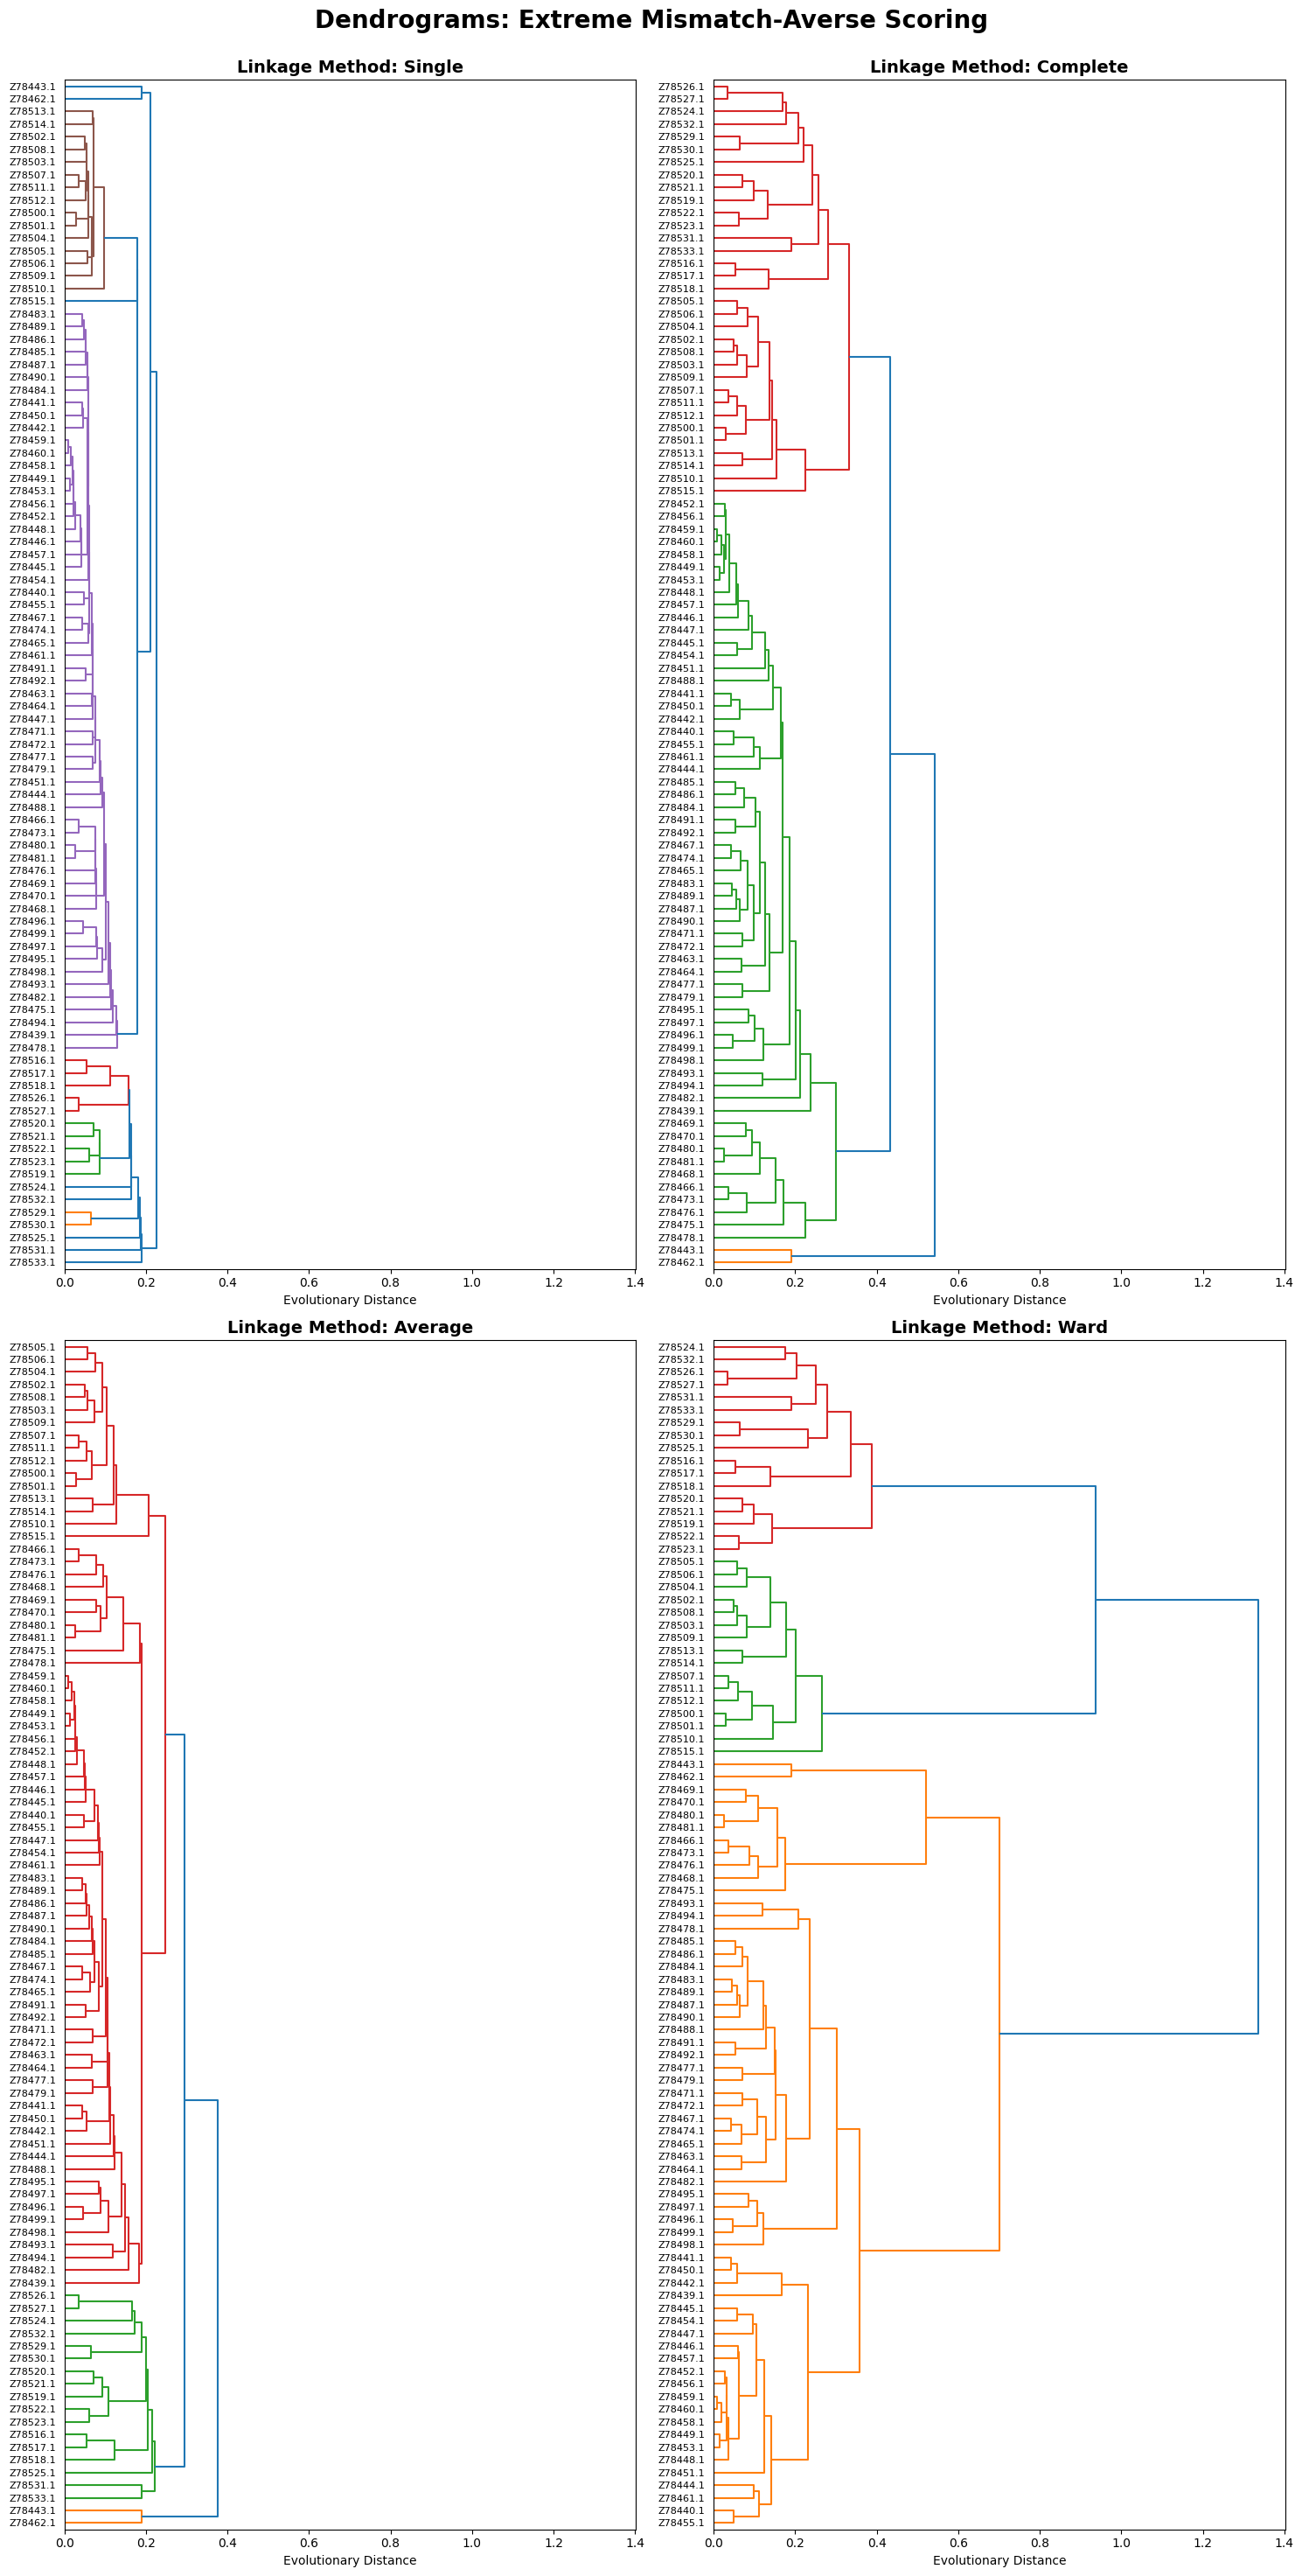

In [12]:
# Compact both matrices for SciPy's linkage function
cdm_blastn = distance.squareform(dm_blastn)
cdm_custom = distance.squareform(dm_custom)

# Define the linkage methods to evaluate
methods = ['single', 'complete', 'average', 'ward']

# Plot the baseline (BLASTN) dendrograms
plot_dendograms(
    cdm_blastn, 
    methods, 
    names, 
    title="Dendrograms: Standard BLASTN Scoring"
)

# Plot the custom scoring dendrograms
plot_dendograms(
    cdm_custom, 
    methods, 
    names, 
    title="Dendrograms: Extreme Mismatch-Averse Scoring"
)

In this final section, we scaled our analysis up to the `ls_orchid.fasta` dataset, which contains nearly 100 sequences. We applied a stretched canvas technique to ensure the dendrograms remained readable and tested our standard `BLASTN` aligner against the "Extreme Mismatch-Averse" aligner to observe how alignment rules impact clustering on a larger scale.


* **Canvas Resizing Success:**
  By dynamically increasing the figure height, the dense, overlapping text was successfully resolved. The individual orchid species labels are now perfectly legible, demonstrating the importance of flexible plotting parameters when moving from toy datasets to real-world bioinformatics data.

* **Extreme Distance Compression:**
  Just as we observed with the smaller dataset, the extreme scoring scheme  collapsed the evolutionary distances. In the standard BLASTN plots, the maximum distance on the horizontal axis reaches approximately **0.30**. In the Extreme plots, the axis maxes out at roughly **0.012**. By making gaps "cheap" and mismatches "expensive," the aligner padded the sequences with gaps to force perfect matches, pushing similarity scores unnaturally close to 100%.

* **Topological Breakdown (The "Ladder" Effect):**
  Unlike the smaller dataset, pushing the aligner to the extreme here completely destroyed the biological structure of the tree. If we look closely at the "Single" and "Average" linkage plots in the Extreme scoring image, the distinct, branching family clades are gone. Instead, the tree forms a massive, cascading "ladder" or "comb." Because nuanced mutations were penalized out of existence, the clustering algorithm lost the ability to group distinct sub-families accurately.
  
* **Linkage Method Clarity:**
  In the biologically realistic BLASTN model, **Ward's Method** proves to be the most visually effective for large datasets. By minimizing variance within clusters, it forces the dense, highly related orchid sequences into clear, distinct major families, whereas Single Linkage struggles with "chaining" (adding sequences one by one instead of grouping them).

Scaling up the data proves that biological realism in scoring schemes is critical. While the extreme scoring scheme was an excellent stress-test, it ultimately obliterated the deeper evolutionary relationships of the orchids. The standard BLASTN scheme, especially when paired with Ward's or Average (UPGMA) linkage, remains the most reliable and informative method for uncovering true phylogenetic structures in complex datasets.